# 01 · Primeros pasos con `tfmfdd`

Este notebook recorre el flujo completo de detección de fallos con el paquete, paso a paso y sobre el TEP clásico, que cabe en cualquier portátil. Al terminar sabréis cargar datos, ajustar un modelo de normalidad, calcular los estadísticos de monitorización, calibrar los umbrales, medir el resultado y dibujarlo.

Cada bloque dice **qué módulo del paquete está usando**, para que cuando abráis el código fuente sepáis dónde mirar. La regla del notebook es que no hay ninguna función mágica: todo lo que aparece aquí está en un `.py` con su docstring.

Antes de empezar, hace falta el TEP clásico descomprimido en `data/tep_classic/` (44 ficheros `.dat`) y el paquete instalado con `pip install -e .`.

In [1]:
# Los notebooks viven en notebooks/ pero los datos están en data/, en la raíz del
# repositorio. Esta celda sube un nivel si hace falta, para que las rutas funcionen
# igual se abra el notebook desde donde se abra.
import os
from pathlib import Path
if not Path("data").exists() and Path("../data").exists():
    os.chdir("..")
print("Directorio de trabajo:", os.getcwd())

Directorio de trabajo: /tmp/repo/tfm-fdd-core


In [2]:
# Imports. Todo lo que viene del paquete lleva el prefijo tfmfdd.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tfmfdd import data, metrics, plots
from tfmfdd.pca import PCAMonitor
from tfmfdd.preprocessing import Scaler
from tfmfdd import limits

plots.use_style()   # plots.py: estilo único para todas las figuras de la memoria

## 1. Cargar datos → `data.py`

`load_classic(fault, split)` lee un fichero `.dat` y devuelve un DataFrame con el **contrato de columnas** del paquete: `faultNumber`, `simulationRun`, `sample` y luego las 52 variables de proceso. Ese contrato es idéntico para el TEP clásico y para el de Rieth, y es lo que hace que nuestros tres bloques sean comparables.

`fault=0` es operación normal. Del 1 al 21 son los tipos de fallo.

In [3]:
normal = data.load_classic(0, "train")     # d00.dat: operación normal, 500 muestras
print("Forma:", normal.shape)
print("Columnas:", list(normal.columns[:5]), "...", list(normal.columns[-2:]))
normal.head()

Forma: (500, 55)
Columnas: ['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2'] ... ['xmv_10', 'xmv_11']


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,0,1,1,0.24987,3642.6,4539.6,9.2784,27.200,42.248,2704.2,...,53.617,24.708,62.265,22.224,39.724,41.975,50.223,47.411,41.093,18.351
1,0,1,2,0.25118,3694.8,4513.8,9.2831,27.077,42.736,2705.4,...,53.926,24.579,61.306,21.975,40.249,34.187,44.741,47.442,41.303,19.831
2,0,1,3,0.25185,3683.5,4504.9,9.4600,26.987,42.245,2705.2,...,54.032,24.521,60.532,21.640,40.003,43.628,46.032,47.574,41.520,20.426
3,0,1,4,0.25147,3653.9,4531.9,9.3462,26.983,42.656,2706.3,...,53.708,24.558,61.496,22.324,40.161,37.967,43.903,47.606,41.284,19.568
4,0,1,5,0.24107,3629.3,4527.0,9.3406,27.041,42.520,2705.6,...,53.259,24.024,60.781,22.506,40.962,34.247,48.037,47.585,40.949,17.063


Habrá salido un aviso: `d00.dat` viene transpuesto en el fichero original, como 52 filas por 500 columnas, y el cargador lo corrige. Es el único fichero así y es una trampa conocida: cargarlo sin corregir no lanza ningún error, solo produce números sin sentido. La función `_as_samples_by_vars` de `data.py` es la que lo detecta.

`values(df)` extrae solo la matriz numérica de las 52 variables, que es lo que se le pasa a un modelo.

In [4]:
X_normal = data.values(normal)
print("Matriz para el modelo:", X_normal.shape, "(muestras, variables)")

Matriz para el modelo: (500, 52) (muestras, variables)


## 2. Ver qué aspecto tienen las señales

Antes de modelar nada conviene mirar los datos. Aquí van tres variables de proceso en operación normal frente a las mismas tres con el fallo 1, que es un cambio escalón en la relación de alimentación A/C y de los fáciles de ver.

Fíjate en el eje horizontal: en los ficheros de prueba el fallo entra tras la muestra 160, que son 8 horas a 3 minutos por muestra. `data.FAULT_ONSET_TEST` guarda ese número para que nadie lo escriba a mano.

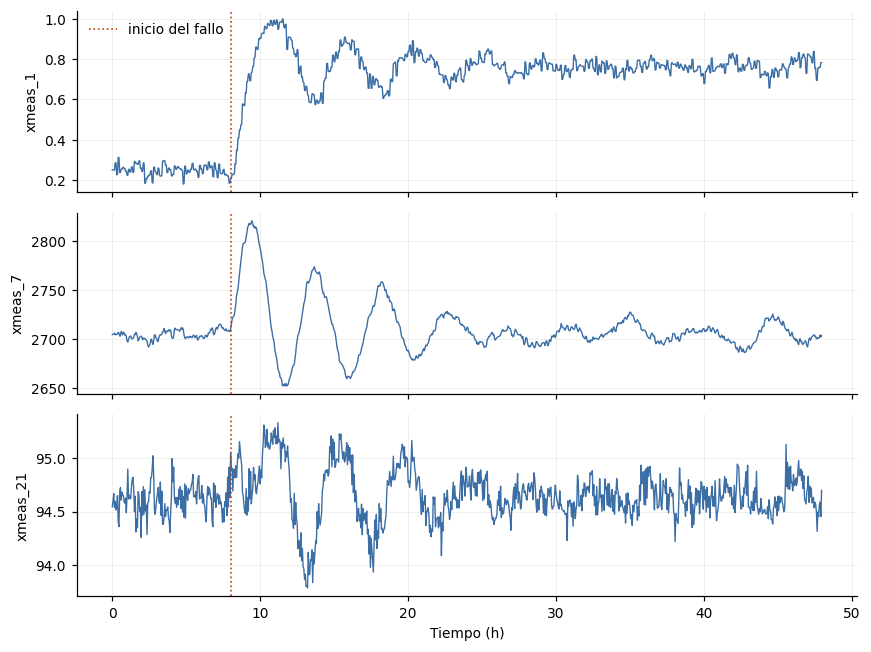

In [5]:
prueba_f1 = data.load_classic(1, "test")   # d01_te.dat: 960 muestras, fallo desde la 161
onset = data.FAULT_ONSET_TEST               # = 160

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
t = np.arange(len(prueba_f1)) * 3 / 60      # horas

for ax, var in zip(axes, ["xmeas_1", "xmeas_7", "xmeas_21"]):
    ax.plot(t, prueba_f1[var], color=plots.COLORS["normal"], lw=0.9)
    ax.axvline(onset * 3 / 60, color=plots.COLORS["fault"], ls=":", label="inicio del fallo")
    ax.set_ylabel(var)

axes[-1].set_xlabel("Tiempo (h)")
axes[0].legend(loc="upper left")
plt.tight_layout()

`xmeas_1` es el caudal de alimentación A y cambia de forma visible; `xmeas_7` es la presión del reactor y reacciona con retraso; `xmeas_21` es la temperatura del agua de refrigeración y apenas se inmuta. Un detector univariante sobre `xmeas_21` no vería nada. El sentido de un método multivariante es justo mirar las 52 a la vez y captar que **la relación entre ellas** se ha roto, aunque cada una por separado siga en rango.

## 3. Ajustar el modelo de normalidad → `pca.py` y `preprocessing.py`

`PCAMonitor` aprende el patrón de operación normal. Internamente hace tres cosas:

1. Estandariza las variables con `Scaler` de `preprocessing.py`, para que un caudal en kg/h y una temperatura en °C pesen lo mismo.
2. Calcula las componentes principales y se queda con las que explican el 85 % de la varianza.
3. Calibra los límites de control de T² y SPE con `limits.py`.

Hay un detalle que **no es opcional**: reservamos parte de los datos normales solo para calibrar los umbrales, sin usarlos en el ajuste. Más abajo se ve por qué con números.

In [6]:
corte = int(len(X_normal) * 0.7)          # 70 % para ajustar, 30 % para calibrar
X_fit, X_cal = X_normal[:corte], X_normal[corte:]

modelo = PCAMonitor(variance=0.85, alpha=0.99).fit(X_fit, X_cal=X_cal)

print(f"Componentes retenidas : {modelo.n_components_} de 52")
print(f"Límite T²  (99 %)     : {modelo.t2_limit_:.2f}")
print(f"Límite SPE (99 %)     : {modelo.spe_limit_:.2f}")
print(f"Calibrado con reserva : {modelo.calibrated_on_holdout_}")

Componentes retenidas : 27 de 52
Límite T²  (99 %)     : 52.63
Límite SPE (99 %)     : 23.46
Calibrado con reserva : True


## 4. Los dos estadísticos → `pca.py`

`score(X)` devuelve T² y SPE para cada observación. Responden a preguntas distintas:

- **T²** mide cuánto se aleja la observación del centro *dentro* del subespacio que el modelo conoce. "¿Sigues el patrón, pero en una zona rara?"
- **SPE** mide cuánto de la observación *no explica* el modelo, es decir el residuo. "¿Es que ya ni siquiera sigues el patrón?"

Un fallo puede disparar uno, otro o los dos, y saber cuál da la primera pista para el diagnóstico.

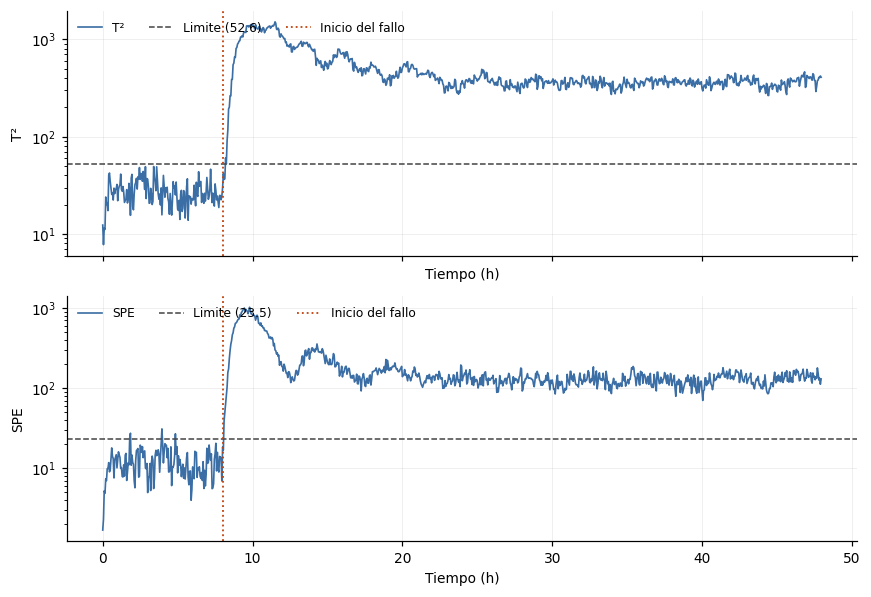

In [7]:
t2, spe = modelo.score(data.values(prueba_f1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)
plots.control_chart(t2,  modelo.t2_limit_,  onset=onset, ylabel="T²",  ax=ax1)
plots.control_chart(spe, modelo.spe_limit_, onset=onset, ylabel="SPE", ax=ax2)
plt.tight_layout()

Esta es **la figura más importante del bloque de detección**, y `control_chart` de `plots.py` la dibuja con el estilo de la memoria. De un vistazo se ve si el método detecta, cuánto tarda y si daba falsas alarmas antes del fallo. El eje vertical va en escala logarítmica porque el estadístico salta varios órdenes de magnitud cuando entra el fallo.

## 5. Medir → `metrics.py`

Tres números, y hay que reportar los tres porque optimizar uno solo engaña:

- **FAR** (tasa de falsas alarmas): sobre las 160 muestras sanas del principio, cuántas marcó.
- **FDR** (tasa de detección): sobre las 800 muestras con fallo, cuántas detectó.
- **Retardo**: cuántas muestras pasaron desde que entró el fallo hasta la primera racha de 3 alarmas consecutivas. Se exige racha porque una exceedencia aislada suele ser ruido.

`evaluate_run` hace las tres cosas de una vez.

In [8]:
res_t2  = metrics.evaluate_run(t2,  modelo.t2_limit_,  onset=onset)
res_spe = metrics.evaluate_run(spe, modelo.spe_limit_, onset=onset)

pd.DataFrame([res_t2, res_spe], index=["T²", "SPE"]).round(3)

,far,fdr,delay_samples,delay_minutes,detected
T²,0.000,0.994,6,18.0,True
SPE,0.025,0.998,2,6.0,True


Los dos estadísticos detectan el fallo 1 casi al instante y sin falsas alarmas. Es el caso fácil. Lo interesante viene al recorrer los 21.

## 6. Los 21 fallos de una vez

Mismo bucle que hace el experimento `experiments/A1_pca_baseline.py`, pero aquí a la vista. El resultado es una fila por fallo y estadístico, que es el formato que después consume `metrics.aggregate` para calcular medias e intervalos de confianza cuando haya muchas simulaciones.

In [9]:
filas = []
for fault in range(22):
    df = data.load_classic(fault, "test")
    t2_f, spe_f = modelo.score(data.values(df))
    onset_f = None if fault == 0 else onset        # el fichero 0 es todo normal

    for nombre, stat, lim in (("T2", t2_f, modelo.t2_limit_), ("SPE", spe_f, modelo.spe_limit_)):
        r = metrics.evaluate_run(stat, lim, onset_f)
        filas.append({"faultNumber": fault, "statistic": nombre, "simulationRun": 1, **r})

resultados = pd.DataFrame(filas)
tabla = resultados.pivot(index="faultNumber", columns="statistic", values=["far", "fdr", "delay_samples"])
tabla.round(3)

far           fdr        delay_samples       
statistic      SPE     T2    SPE     T2           SPE     T2
faultNumber                                                 
0            0.028  0.015    NaN    NaN           NaN    NaN
1            0.025  0.000  0.998  0.994           2.0    6.0
2            0.050  0.006  0.989  0.982          10.0   14.0
3            0.125  0.006  0.038  0.045         537.0   42.0
4            0.031  0.012  0.984  0.420           4.0   63.0
5            0.031  0.012  0.291  0.284           2.0    0.0
6            0.012  0.000  1.000  0.994           0.0    5.0
7            0.012  0.000  1.000  1.000           0.0    0.0
8            0.006  0.000  0.974  0.974          21.0   22.0
9            0.044  0.050  0.058  0.031         223.0    5.0
10           0.019  0.000  0.471  0.464          34.0   22.0
11           0.031  0.019  0.609  0.526           8.0    5.0
12           0.081  0.006  0.975  0.988           2.0    2.0
13           0.012  0.006  0.954  0.950          36.0   38.0
14           0.031  0.006  0.999  0.996           1.0    0.0
15           0.031  0.000  0.084  0.079          92.0  577.0
16           0.056  0.138  0.404  0.281          35.0  196.0
17           0.019  0.012  0.945  0.808          23.0   28.0
18           0.056  0.000  0.905  0.892          78.0   88.0
19           0.012  0.006  0.179  0.071          80.0   76.0
20           0.006  0.000  0.554  0.449          80.0   84.0
21           0.056  0.012  0.582  0.396         241.0  284.0

Mirad las filas **3, 9 y 15**. Son los fallos que casi nadie detecta, y `metrics.HARD_FAULTS` los tiene apuntados para que siempre se reporten aparte. Promediarlos con el resto esconde el único sitio donde los métodos se diferencian de verdad. El fallo 3 es un cambio escalón en la temperatura de alimentación D, el 9 una variación aleatoria de esa misma temperatura, y el 15 un agarrotamiento de la válvula del condensador; su firma en las 52 variables es tan pequeña que apenas se separa del ruido.

FDR medio, todos los fallos      : 0.666
FDR medio, sin 3, 9 y 15         : 0.767
FDR medio, solo 3, 9 y 15        : 0.060


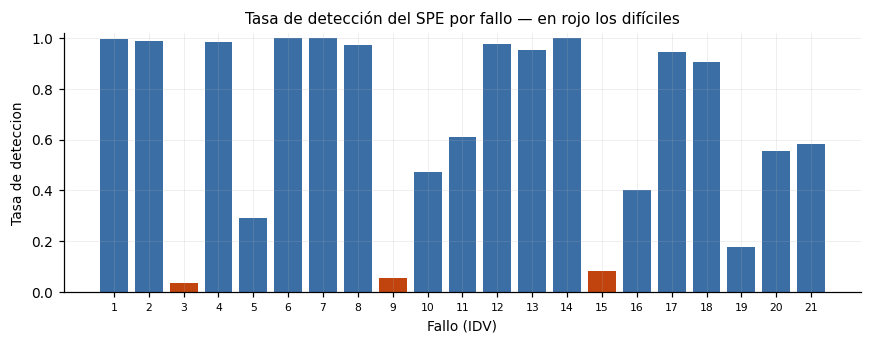

In [10]:
agg = metrics.aggregate(resultados[resultados["statistic"] == "SPE"])
fig, ax = plt.subplots(figsize=(8, 3.2))
plots.fdr_by_fault(agg, ax=ax)
ax.set_title("Tasa de detección del SPE por fallo — en rojo los difíciles")
plt.tight_layout()

resumen = metrics.summary(agg)
print(f"FDR medio, todos los fallos      : {resumen['fdr_medio_todos']:.3f}")
print(f"FDR medio, sin 3, 9 y 15         : {resumen['fdr_medio_sin_dificiles']:.3f}")
print(f"FDR medio, solo 3, 9 y 15        : {resumen['fdr_medio_dificiles']:.3f}")

## 7. Por qué se calibra con datos reservados → `limits.py`

Esta es la parte que más conviene entender, porque afecta a los tres bloques y porque es un hallazgo que va a la memoria.

El modelo se ajusta *minimizando* el residuo sobre sus datos de entrenamiento. Por tanto, el SPE que observa sobre esos mismos datos es artificialmente pequeño. Si el umbral se calibra ahí, sale demasiado estrecho, y en cuanto llegan datos que el modelo no ha visto el estadístico lo supera continuamente.

Lo comprobamos con los mismos datos y las mismas componentes, cambiando solo de dónde sale el umbral.

In [11]:
n_comp = modelo.n_components_

# A) calibrar con los datos del ajuste (lo que hace buena parte de la literatura)
sin_reserva = PCAMonitor(n_components=n_comp, alpha=0.99).fit(X_normal)

# B) calibrar con datos reservados (lo que hacemos nosotros)
con_reserva = PCAMonitor(n_components=n_comp, alpha=0.99).fit(X_fit, X_cal=X_cal)

# FAR medido sobre las 160 muestras sanas de los 21 ficheros de fallo
def far_media(m):
    fars = []
    for f in range(1, 22):
        _, spe_f = m.score(data.values(data.load_classic(f, "test")))
        fars.append(metrics.far(spe_f[:onset], m.spe_limit_))
    return np.mean(fars)

print(f"Límite SPE sin reserva : {sin_reserva.spe_limit_:6.2f}  →  FAR = {far_media(sin_reserva):.3f}")
print(f"Límite SPE con reserva : {con_reserva.spe_limit_:6.2f}  →  FAR = {far_media(con_reserva):.3f}")

Límite SPE sin reserva :  15.07  →  FAR = 0.199
Límite SPE con reserva :  23.46  →  FAR = 0.036


Varias veces más falsas alarmas por calibrar en el sitio equivocado. Ninguna fórmula estaba mal: `spe_limit_box`, `spe_limit_jackson` y `limit_empirical` de `limits.py` dan valores casi iguales entre sí. El problema era la procedencia de los datos con los que se calibra.

Es una forma de fuga de datos poco discutida, y por eso `PCAMonitor.fit` tiene el parámetro `X_cal` y por eso **el umbral de cualquier detector de los tres bloques** —incluido el error de reconstrucción del autoencoder— se calibra con datos normales que el modelo no haya visto.

## 8. Qué variable se ha ido → `pca.py`

`contributions(x)` descompone el SPE de una observación en la parte que aporta cada variable. No identifica la causa raíz, porque un fallo se propaga por la planta, pero acota dónde mirar. Aquí, la observación 300 del fallo 1.

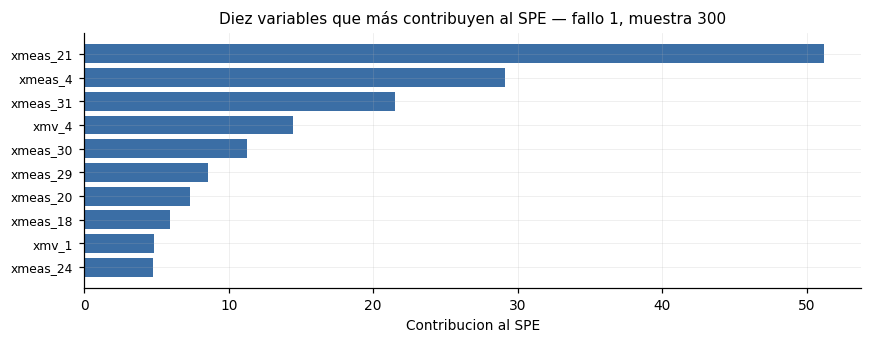

In [12]:
x_obs = data.values(prueba_f1)[300]
contrib = modelo.contributions(x_obs)

fig, ax = plt.subplots(figsize=(8, 3.2))
plots.contribution_plot(contrib, data.VAR_NAMES, top=10, ax=ax)
ax.set_title("Diez variables que más contribuyen al SPE — fallo 1, muestra 300")
plt.tight_layout()

## Dónde está cada cosa

| Lo que hicimos | Módulo | Función |
|---|---|---|
| Cargar un fichero | `data.py` | `load_classic`, `load_rieth`, `values` |
| Saber dónde entra el fallo | `data.py` | `FAULT_ONSET_TEST` |
| Estandarizar | `preprocessing.py` | `Scaler` |
| Ajustar y puntuar | `pca.py` | `PCAMonitor.fit`, `.score`, `.contributions` |
| Umbrales | `limits.py` | `t2_limit`, `spe_limit_box`, `limit_empirical`, … |
| FAR, FDR, retardo | `metrics.py` | `evaluate_run`, `aggregate`, `summary` |
| Figuras | `plots.py` | `control_chart`, `fdr_by_fault`, `contribution_plot` |

El experimento completo, con argumentos por línea de comandos y guardado de resultados, está en `experiments/A1_pca_baseline.py`. Este notebook es ese script abierto por dentro.